Neste notebook estarei implementando uma rede neural autoencoder convolucional.

A rede neural será uma mescla entre CNNs e autoencoders.

A imagem original passada para a rede sofrerá diminuição de dimensionalidade, ou seja, compressão, através de aplicações de kernels (Os feature maps serão versões de suas imagens originais correspondentes com dimensões menores), e posteriormente passará por camadas de deconvolução para reconstruir a imagem original.

In [1]:
from torchvision import datasets, transforms
import torch
from torch import nn, optim
import matplotlib.pyplot as plt

Construção da base de dados:

In [2]:
dataset_train = datasets.MNIST('../', train = True, download = True, transform = transforms.ToTensor())
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 128, shuffle = True)

dataset_test = datasets.MNIST('../', train = False, download = True, transform = transforms.ToTensor())
loader_test = torch.utils.data.DataLoader(dataset_test, batch_size = 128, shuffle = True)

Definição do Autoencoder:

In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
                                     # 28 -> 26
                                     nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = (3, 3)),
                                     nn.ReLU(),
                                     # 26 -> 13
                                     nn.MaxPool2d(kernel_size = (2, 2)),
                                     
                                     # 13 -> 13
                                     nn.Conv2d(in_channels = 16, out_channels = 8, kernel_size = (3, 3), padding = (1, 1)),
                                     nn.ReLU(),
                                     # 13 -> 7
                                     nn.MaxPool2d(kernel_size = (2, 2), padding = (1, 1)),
                                     
                                     # 7 -> 4
                                     nn.Conv2d(in_channels = 8, out_channels = 8, kernel_size = (3, 3), stride = (2, 2), padding = (1, 1)),
                                     nn.ReLU(),
                                   )

        self.decoder = nn.Sequential(
            # 4 -> 7
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # 7 -> 13
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # 13 -> 26  (aqui precisa output_padding=1)
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # 26 -> 28
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=1, padding=0, output_padding=0),

            nn.Sigmoid()
        )
            
    def forward(self, X):
        encoded = self.encoder(X)
        if encoded.dim() == 2:
            encoded = encoded.view(encoded.size(0), 8, 4, 4)
        return self.decoder(encoded)

In [4]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [5]:
model = Autoencoder().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

Treinamento:

In [6]:
for epoch in range(50):
    # Treinamento
    total_loss_train = 0.0
    model.train()

    for inputs, _ in loader_train:
        inputs = inputs.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        targets = inputs.view(*outputs.shape)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()
    
    # Teste
    total_loss_val = 0.0
    model.eval()

    with torch.no_grad():
        for inputs, _ in loader_test:
            inputs = inputs.to(device)
            outputs = model(inputs)

            targets = inputs.view(*outputs.shape)
            loss = criterion(outputs, targets)
            
            total_loss_val += loss.item()
        
    # Final da época
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(epoch + 1, total_loss_train/len(loader_train), total_loss_val/len(loader_test)))

ÉPOCA   1: perda_train 0.28332 perda_val 0.12014
ÉPOCA   2: perda_train 0.11040 perda_val 0.10296
ÉPOCA   3: perda_train 0.10157 perda_val 0.09785
ÉPOCA   4: perda_train 0.09786 perda_val 0.09549
ÉPOCA   5: perda_train 0.09572 perda_val 0.09379
ÉPOCA   6: perda_train 0.09414 perda_val 0.09235
ÉPOCA   7: perda_train 0.09284 perda_val 0.09142
ÉPOCA   8: perda_train 0.09172 perda_val 0.09012
ÉPOCA   9: perda_train 0.09054 perda_val 0.08878
ÉPOCA  10: perda_train 0.08903 perda_val 0.08723
ÉPOCA  11: perda_train 0.08776 perda_val 0.08605
ÉPOCA  12: perda_train 0.08678 perda_val 0.08539
ÉPOCA  13: perda_train 0.08602 perda_val 0.08467
ÉPOCA  14: perda_train 0.08539 perda_val 0.08410
ÉPOCA  15: perda_train 0.08488 perda_val 0.08360
ÉPOCA  16: perda_train 0.08440 perda_val 0.08348
ÉPOCA  17: perda_train 0.08405 perda_val 0.08265
ÉPOCA  18: perda_train 0.08371 perda_val 0.08241
ÉPOCA  19: perda_train 0.08339 perda_val 0.08238
ÉPOCA  20: perda_train 0.08313 perda_val 0.08185
ÉPOCA  21: perda_tra

Definição do encoder:

In [12]:
class Encoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.model = autoencoder.encoder
        self.flatten = nn.Flatten()
    
    def forward(self, X):
        return self.flatten(self.model(X))

Definição do decoder:

In [9]:
class Decoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.model = autoencoder.decoder
    
    def forward(self, X):
        # aceita tanto (N, 128) quanto (N, 8, 4, 4)
        if X.dim() == 2:
            X = X.view(X.size(0), 8, 4, 4)
        return self.model(X)

In [15]:
encoder = Encoder(model).to(device)
decoder = Decoder(model).to(device)

Visualização dos resultados:

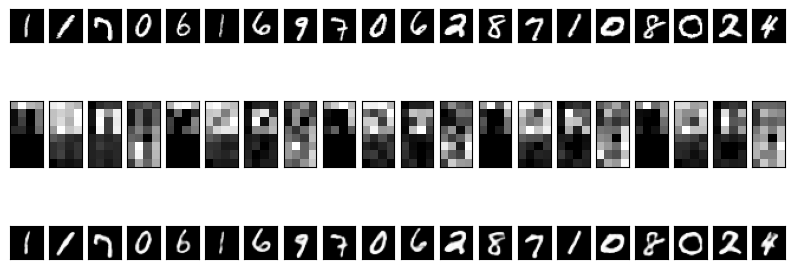

In [16]:
numero_imagens = 20
# Pega 20 imagens do batch 0
imagens_teste = (next(iter(loader_test))[0][:numero_imagens]).to(device)

encoder.eval()
imagens_codificadas = encoder(imagens_teste)

decoder.eval()
imagens_decodificadas = decoder(imagens_codificadas)

imagens_teste_plt = imagens_teste.view(-1, 28, 28).detach().cpu().numpy()
imagens_codificadas_plt = imagens_codificadas.view(-1, 8, 4).detach().cpu().numpy()
imagens_decodificadas_plt = imagens_decodificadas.view(-1, 28, 28).detach().cpu().numpy()

fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste_plt, imagens_codificadas_plt, imagens_decodificadas_plt], axes):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img, cmap = 'gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

# Autoencoder Convolucional (MNIST) — Lógica, Arquitetura e Hiperparâmetros

## Objetivo
Treinar um **autoencoder convolucional** para **reconstruir imagens de dígitos do MNIST** (1 canal, 28×28).  
O modelo aprende uma **representação comprimida (latent / bottleneck)** no encoder e usa o decoder para reconstruir a imagem original.

---

## Dados e pré-processamento
- **Dataset:** MNIST
- **Entrada:** imagens em escala de cinza com shape `(N, 1, 28, 28)`
- **Transformação:** `ToTensor()`  
  Isso converte pixels para `float` em `[0, 1]`, o que é compatível com saída `Sigmoid()` no decoder.

---

## Visão geral da arquitetura

### Ideia central
- **Encoder:** reduz gradualmente a resolução espacial e aprende mapas de características (features).
- **Bottleneck:** representa a imagem comprimida como um tensor pequeno.
- **Decoder:** faz o caminho inverso, aumentando a resolução e reconstruindo os pixels.

### Por que usar convoluções?
- Convoluções exploram a estrutura local das imagens (bordas, traços, curvas).
- Ao contrário de redes totalmente conectadas, elas reaproveitam pesos e funcionam melhor com dados espaciais.

---

## Encoder (compressão)

### Código (resumo)
- Conv2d(1→16, 3×3, padding=0) + ReLU
- MaxPool2d(2×2)
- Conv2d(16→8, 3×3, padding=1) + ReLU
- MaxPool2d(2×2, padding=1)
- Conv2d(8→8, 3×3, stride=2, padding=1) + ReLU

### Dimensões camada a camada (MNIST: 28×28)

#### Entrada
- `(N, 1, 28, 28)`

#### 1) Conv2d(1→16, k=3, pad=0, stride=1)
- 28 → 26 (reduz 2 pixels por dimensão)
- `(N, 16, 26, 26)`
**Justificativa:** um primeiro extrator de features simples (bordas/traços).  
O `kernel 3×3` é um padrão eficiente (bom custo/benefício).

#### 2) MaxPool2d(k=2)
- 26 → 13
- `(N, 16, 13, 13)`
**Justificativa:** downsampling para reduzir custo e forçar compressão.

#### 3) Conv2d(16→8, k=3, pad=1)
- 13 → 13 (mantém tamanho)
- `(N, 8, 13, 13)`
**Justificativa:** reduzir canais (16→8) e refinar features mantendo a resolução.

#### 4) MaxPool2d(k=2, pad=1)
- 13 → 7 (efeito de arredondamento devido ao padding)
- `(N, 8, 7, 7)`
**Justificativa:** continuar compressão espacial.

#### 5) Conv2d(8→8, k=3, stride=2, pad=1)
- 7 → 4
- `(N, 8, 4, 4)`
**Justificativa:** mais compressão (stride 2), mantendo número de canais.

### Bottleneck (representação comprimida)
- Shape: `(N, 8, 4, 4)`  
- Tamanho total: `8 * 4 * 4 = 128` valores por imagem.

**Interpretação:** em vez de 784 pixels (28×28), a rede tenta representar a imagem com **128 valores**, mantendo informação suficiente para reconstrução.

---

## Decoder (reconstrução)

### Por que ConvTranspose2d?
Para **aumentar a resolução**, `Conv2d` comum não ajuda (ele só mantém ou reduz H×W).  
A `ConvTranspose2d` (convolução transposta) permite **upsampling treinável**, ou seja, o modelo aprende **como expandir** a imagem.

> Observação: ConvTranspose pode gerar artefatos (checkerboard) dependendo de `stride/kernel/padding`, então escolhemos configurações que batem dimensões com controle fino via `output_padding`.

### Código (resumo)
- ConvTranspose2d(8→16, k=3, stride=2, pad=1, output_padding=0) + ReLU
- ConvTranspose2d(16→16, k=3, stride=2, pad=1, output_padding=0) + ReLU
- ConvTranspose2d(16→8, k=3, stride=2, pad=1, output_padding=1) + ReLU
- ConvTranspose2d(8→1, k=3, stride=1, pad=0) + Sigmoid

### Dimensões camada a camada

#### Entrada do decoder (bottleneck)
- `(N, 8, 4, 4)`

#### 1) ConvTranspose2d(8→16, k=3, stride=2, pad=1, output_padding=0)
- 4 → 7
- `(N, 16, 7, 7)`
**Justificativa:** inverter parte do downsampling (stride 2) e aumentar capacidade (8→16 canais).

#### 2) ConvTranspose2d(16→16, k=3, stride=2, pad=1, output_padding=0)
- 7 → 13
- `(N, 16, 13, 13)`
**Justificativa:** continuar aumento de resolução mantendo canais.

#### 3) ConvTranspose2d(16→8, k=3, stride=2, pad=1, output_padding=1)
- 13 → 26  
- `(N, 8, 26, 26)`
**Justificativa:** aqui usamos `output_padding=1` para fechar exatamente o tamanho 26 (senão daria 25).
Esse detalhe compensa o “caminho não-potência-de-2” causado pelo pooling com padding no encoder.

#### 4) ConvTranspose2d(8→1, k=3, stride=1, pad=0)
- 26 → 28
- `(N, 1, 28, 28)`
**Justificativa:** último ajuste de tamanho e conversão para 1 canal (imagem final).

#### Saída: Sigmoid()
- Mantém valores em `[0, 1]`, compatível com imagens normalizadas pelo `ToTensor()`.

---

## Função de perda e justificativa
- **Loss:** `BCELoss()`
- **Motivo:** como a saída usa `Sigmoid()` e os pixels do MNIST estão em `[0,1]`, podemos modelar a reconstrução como uma “probabilidade” por pixel (visão de Bernoulli / intensidade normalizada).

> Alternativa comum: `MSELoss()` (erro quadrático). BCE costuma funcionar bem com MNIST + Sigmoid, mas MSE também é válido.

---

## Otimizador e hiperparâmetros

### Otimizador
- **Adam**: `optim.Adam(model.parameters())`
- **Justificativa:** Adam ajusta automaticamente taxas de aprendizado por parâmetro (bom padrão para começar), e costuma convergir rápido em redes convolucionais.

> Observação: o Adam default usa `lr=1e-3`, que é uma taxa inicial típica.

### Batch size
- **batch_size = 128**
- **Justificativa:** equilíbrio entre estabilidade do gradiente e eficiência computacional.

### Número de épocas
- **50 épocas**
- **Justificativa:** suficiente para o autoencoder aprender reconstrução boa no MNIST sem precisar de tuning fino inicialmente.

### Device
- Usa GPU se disponível (`cuda`), senão CPU.
- **Justificativa:** acelera bastante convoluções e treino em batches.

---

## Resumo das escolhas (por que essa arquitetura faz sentido)

1. **Kernel 3×3** em todas as convoluções  
   - padrão eficiente, bom para extrair detalhes locais (traços finos do MNIST).

2. **Compressão espacial agressiva (28→4)**  
   - força o modelo a aprender uma representação compacta (bottleneck de 128 valores).

3. **ConvTranspose2d no decoder**  
   - permite reconstrução com upsampling treinável e bate dimensões exatamente (28×28).

4. **Sigmoid + BCE**  
   - combina com intensidades normalizadas em `[0,1]` do MNIST.
